In [ ]:
import xarray as xr

folder = "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses/snow_cover/composite"
obs = xr.open_dataset(f"{folder}/MF_FSC_VNP_20220226.nc")

In [ ]:
def format_viirs_for_soda(obs: xr.Dataset):
    obs = obs.drop_vars(("sensor_zenith_angle", "platform"))
    obs = obs.rename({"snow_cover_fraction": "SCF", "x": "xx", "y": "yy"})
    obs = obs.reindex(yy=obs.coords["yy"].sortby("yy"), xx=obs.coords["xx"].sortby("xx"))
    obs.data_vars["SCF"].encoding["dtype"] = "float64"
    obs = obs.fillna(1e20)
    obs.data_vars["SCF"].encoding["missing_value"] = 1e20
    obs.data_vars["SCF"][:] = obs.data_vars["SCF"].values / 200
    obs.data_vars["SCF"][:] = obs.data_vars["SCF"].where(obs.data_vars["SCF"] <= 1, 1e20).values

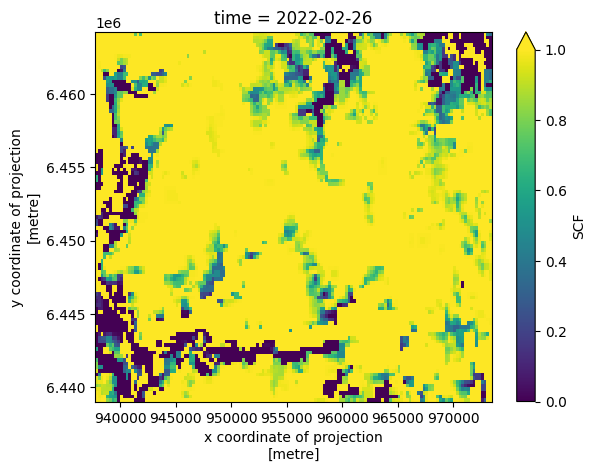

In [ ]:
obs.data_vars["SCF"].plot.imshow(vmax=1)